--- Sequential Cycle Discovery ---
INFO: Treating 30.46d period as a monthly calendar cycle.
Cycle #1 (30.46d): KEPT. Score: 0.0851, Phase: 0 days.
INFO: Treating 30.46d period as a monthly calendar cycle.
Cycle #2 (30.46d): KEPT. Score: 0.0417, Phase: 26 days.
------------------------------

--- Poisson Intensity Results (MLE) ---
Period Type: Background
  - Total Days (T): 506, Total Events (n): 0
  - Estimated Intensity (λ): 0.0000 +/- 0.0000
Period Type: Cycle_1_30d
  - Total Days (T): 118, Total Events (n): 11
  - Estimated Intensity (λ): 0.0932 +/- 0.0281
Period Type: Cycle_2_30d
  - Total Days (T): 107, Total Events (n): 5
  - Estimated Intensity (λ): 0.0467 +/- 0.0209
------------------------------

--- Forward Prediction Table ---
 start_date    end_date Expected Events
25 Jan 2025 29 Jan 2025   0.47 +/- 0.14
25 Feb 2025 01 Mar 2025   0.47 +/- 0.14
25 Mar 2025 29 Mar 2025   0.47 +/- 0.14
------------------------------



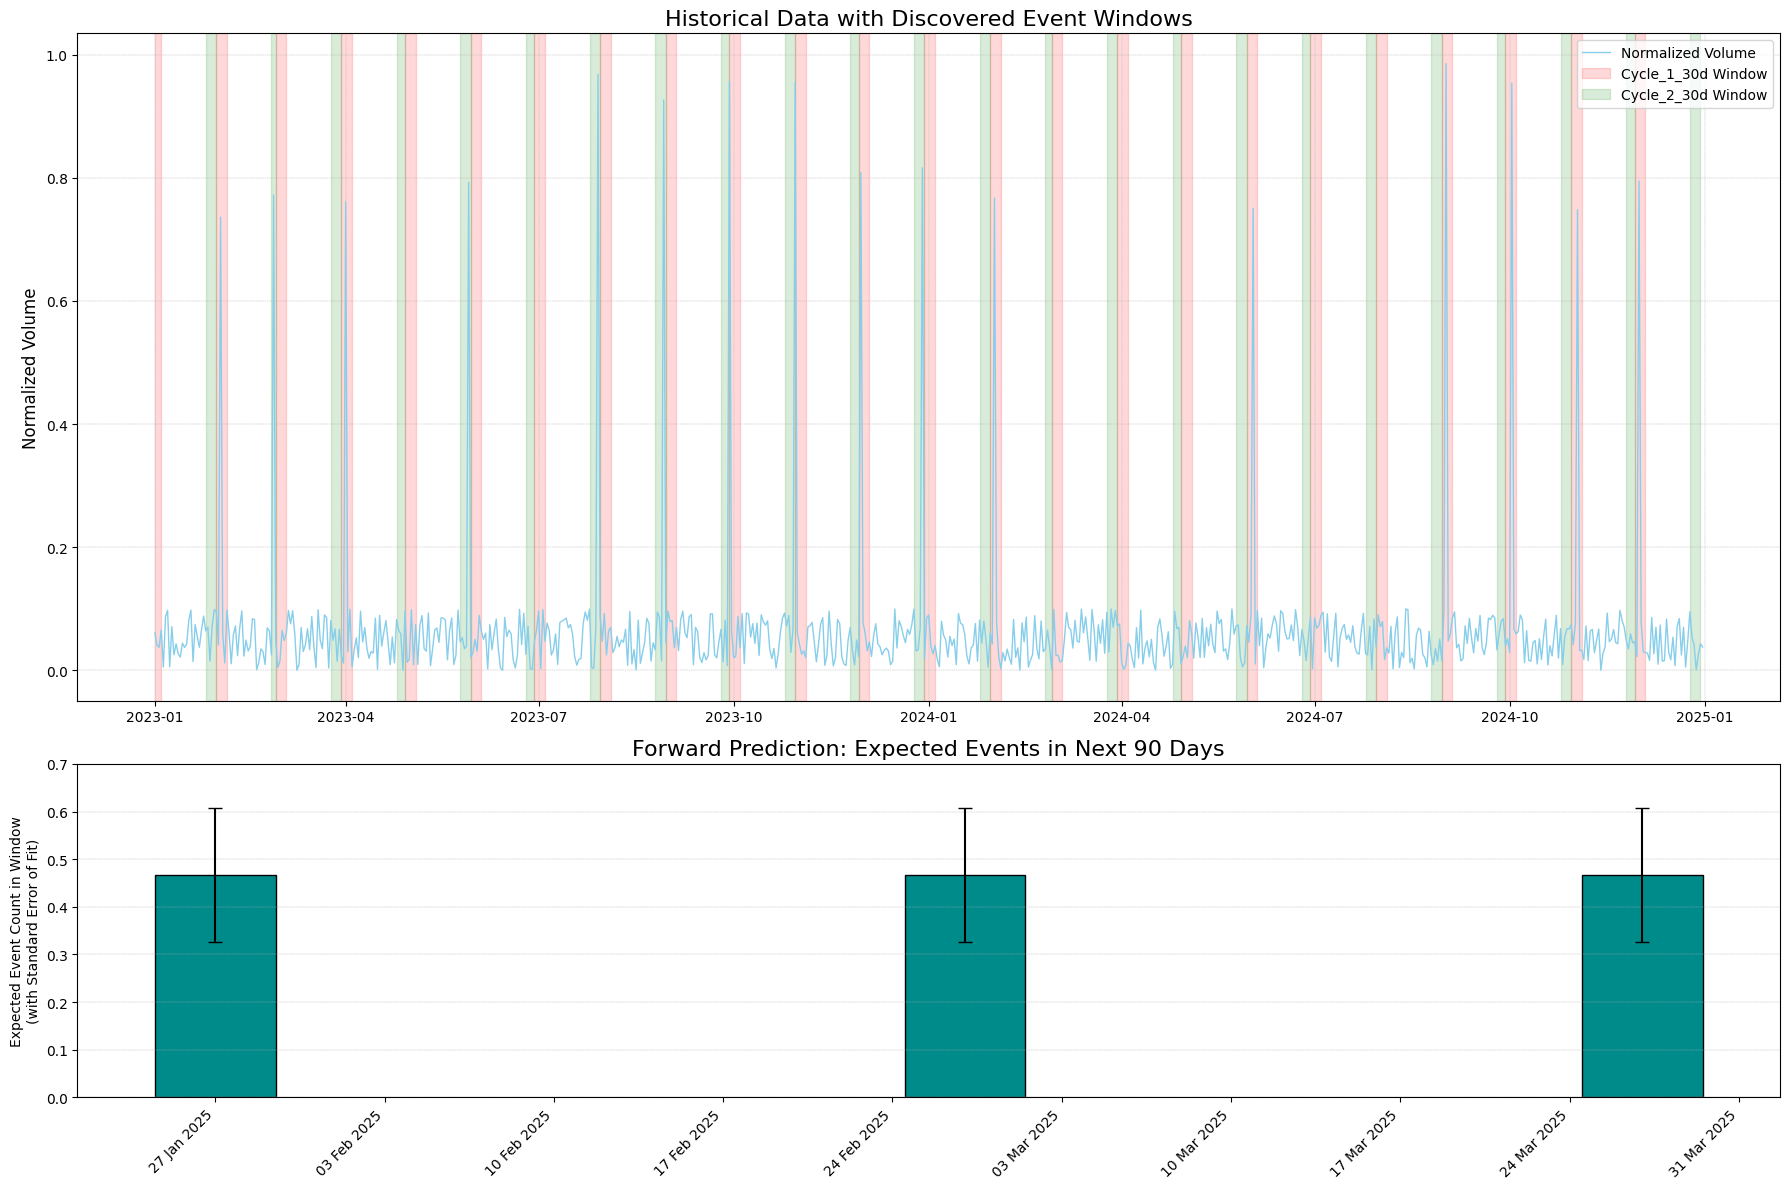

In [146]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.signal import periodogram
from datetime import datetime, timedelta

# --- Configuration for the Prediction Model ---

# Step 1: Binarization
EVENT_THRESHOLD = 0.65 # Volumes above this are considered an "event"

# Step 2: Cycle Discovery
NUM_CYCLES_TO_FIND = 2 # The *maximum* number of cycles to search for
MIN_PERIOD_DAYS = 15   # Ignore cycles shorter than this (e.g., weekly noise)
MAX_PERIOD_DAYS = 120  # Ignore cycles longer than this (e.g., yearly trends)

# Step 3: Classification
CYCLE_WINDOW_DAYS = 2  # +/- days to define the event window around a cycle date
NON_CAPTURED_EVENT_PENALTY = 1.0
MINIMUM_CONCENTRATION_SCORE = 0.005 # A cycle's score must be above this to be kept.

# Step 5: Prediction
PREDICTION_DAYS_AHEAD = 90 # How many days into the future to predict

# --- Previous Simulation Code (to generate input data) ---
def is_imm_date(date):
    return (date.weekday() == 2 and date.month in [3, 6, 9, 12] and 15 <= date.day <= 21)

def run_simulation(start_date, end_date):
    dates = pd.date_range(start=start_date, end=end_date, freq='D')
    df = pd.DataFrame(index=dates)
    df['volume'] = np.random.uniform(0.0, 0.1, size=len(dates))
    df['true_event_type'] = 'None'

    # Configuration for simulation
    MAX_EVENT_SHIFT_DAYS = 2
    P_IMM_EVENT = 0.0
    P_MONTH_END_EVENT = 0.8
    P_NOISE_EVENT = 0.001
    EVENT_VOLUME_RANGE = [0.7, 1.0]

    potential_imm_dates = [d for d in dates if is_imm_date(d)]
    potential_month_end_dates = [d for d in dates if d.is_month_end]

    event_calendar = {}
    for date in potential_imm_dates:
        shift = np.random.randint(-MAX_EVENT_SHIFT_DAYS, MAX_EVENT_SHIFT_DAYS + 1)
        shifted_date = date + pd.Timedelta(days=int(shift))
        if shifted_date in df.index:
            event_calendar[shifted_date] = 'IMM'

    for date in potential_month_end_dates:
        shift = np.random.randint(-MAX_EVENT_SHIFT_DAYS, MAX_EVENT_SHIFT_DAYS + 1)
        shifted_date = date + pd.Timedelta(days=int(shift))
        if shifted_date in df.index and shifted_date not in event_calendar:
            event_calendar[shifted_date] = 'Month-End'

    for date in df.index:
        is_event = False
        if date in event_calendar:
            event_type = event_calendar[date]
            prob = P_IMM_EVENT if event_type == 'IMM' else P_MONTH_END_EVENT
            if np.random.rand() < prob:
                df.loc[date, 'true_event_type'] = event_type
                is_event = True
        elif np.random.rand() < P_NOISE_EVENT:
            df.loc[date, 'true_event_type'] = 'Noise'
            is_event = True

        if is_event:
            df.loc[date, 'volume'] = np.random.uniform(*EVENT_VOLUME_RANGE)

    return df

# --- NEW: Helper function to make cycle frequency calendar-aware ---
def get_calendar_aware_offset(period_days):
    """
    If a period is close to monthly or quarterly, return a calendar offset.
    Otherwise, return a fixed-day offset.
    """
    if 28 <= period_days <= 33:
        print(f"INFO: Treating {period_days:.2f}d period as a monthly calendar cycle.")
        return pd.DateOffset(months=1)
    elif 88 <= period_days <= 94:
        print(f"INFO: Treating {period_days:.2f}d period as a quarterly calendar cycle.")
        return pd.DateOffset(months=3)
    else:
        return pd.DateOffset(days=round(period_days))


# --- Modified Algorithm Implementation ---

def analyze_and_predict(time_series_df):
    """
    Main function to run the discovery and prediction algorithm using a sequential,
    greedy, and now CALENDAR-AWARE approach to find cycles.
    """
    df = time_series_df.copy()

    # --- Step 1: Binarize the Events ---
    df['is_event'] = (df['volume'] >= EVENT_THRESHOLD).astype(int)

    # --- Step 2 & 3: Sequential Cycle Discovery, Phasing, and Thresholding ---
    df['period_type'] = 'Background'
    optimal_phases = {}
    validated_periods = []

    residual_events = df['is_event'].copy()

    print("--- Sequential Cycle Discovery ---")
    for cycle_num in range(1, NUM_CYCLES_TO_FIND + 1):
        if residual_events.sum() == 0:
            print("No residual events left to analyze. Stopping search.")
            break

        fs = 1
        frequencies, power_spectrum = periodogram(residual_events, fs=fs, window='blackmanharris')

        if len(frequencies) > 1 and frequencies[0] == 0:
            frequencies, power_spectrum = frequencies[1:], power_spectrum[1:]

        if len(frequencies) == 0:
            print("No frequencies left to analyze.")
            break

        periods = 1 / frequencies
        valid_indices = (periods >= MIN_PERIOD_DAYS) & (periods <= MAX_PERIOD_DAYS)
        periods, power_spectrum = periods[valid_indices], power_spectrum[valid_indices]

        if len(power_spectrum) == 0:
            print("No further dominant cycles found in residuals.")
            break

        top_period_idx = np.argmax(power_spectrum)
        period_days = periods[top_period_idx]

        calendar_offset = get_calendar_aware_offset(period_days)

        start_series_date = df.index[0]
        best_phase, best_score = 0, -np.inf
        total_residual_events = residual_events.sum()
        total_days = len(df)

        for phase_shift in range(int(period_days)):
            is_in_window = pd.Series(False, index=df.index)
            temp_cycle_dates = pd.date_range(start=start_series_date + timedelta(days=phase_shift),
                                             end=df.index[-1], freq=calendar_offset)
            for date in temp_cycle_dates:
                start, end = date - timedelta(days=CYCLE_WINDOW_DAYS), date + timedelta(days=CYCLE_WINDOW_DAYS)
                is_in_window.loc[start:end] = True

            days_in_window = is_in_window.sum()
            if days_in_window == 0: continue

            events_in_window = residual_events[is_in_window].sum()
            days_outside_window = total_days - days_in_window
            events_outside_window = total_residual_events - events_in_window
            intensity_in = events_in_window / days_in_window
            intensity_out = events_outside_window / days_outside_window if days_outside_window > 0 else 0
            score = intensity_in - NON_CAPTURED_EVENT_PENALTY * intensity_out

            if score > best_score:
                best_score, best_phase = score, phase_shift

        if best_score >= MINIMUM_CONCENTRATION_SCORE:
            print(f"Cycle #{cycle_num} ({period_days:.2f}d): KEPT. Score: {best_score:.4f}, Phase: {best_phase} days.")
            validated_periods.append({'period_days': period_days, 'offset': calendar_offset})
            optimal_phases[period_days] = best_phase

            cycle_label = f'Cycle_{len(validated_periods)}_{int(round(period_days))}d'
            final_cycle_dates = pd.date_range(start=start_series_date + timedelta(days=best_phase),
                                              end=df.index[-1], freq=calendar_offset)
            for date in final_cycle_dates:
                start, end = date - timedelta(days=CYCLE_WINDOW_DAYS), date + timedelta(days=CYCLE_WINDOW_DAYS)
                df.loc[(df.index >= start) & (df.index <= end) & (df['period_type'] == 'Background'), 'period_type'] = cycle_label

            is_in_best_window = pd.Series(False, index=df.index)
            for date in final_cycle_dates:
                start, end = date - timedelta(days=CYCLE_WINDOW_DAYS), date + timedelta(days=CYCLE_WINDOW_DAYS)
                is_in_best_window.loc[start:end] = True
            residual_events[is_in_best_window] = 0

        else:
            print(f"Cycle #{cycle_num} ({period_days:.2f}d): DROPPED. Score ({best_score:.4f}) too low. Stopping search.")
            break
    print("-" * 30 + "\n")

    # --- Step 4: Calculate Final Intensities ---
    intensity_results = {}
    grouped = df.groupby('period_type')

    print("--- Poisson Intensity Results (MLE) ---")
    for name, group in grouped:
        n_events, T_days = group['is_event'].sum(), len(group)
        intensity = n_events / T_days if T_days > 0 else 0
        std_error = np.sqrt(intensity / T_days) if T_days > 0 else 0
        intensity_results[name] = {'intensity': intensity, 'std_error': std_error}
        print(f"Period Type: {name}")
        print(f"  - Total Days (T): {T_days}, Total Events (n): {n_events}")
        print(f"  - Estimated Intensity (λ): {intensity:.4f} +/- {std_error:.4f}")
    print("-" * 30 + "\n")

    # --- Step 5: Forward Prediction ---
    last_date = df.index[-1]
    prediction_dates = pd.date_range(start=last_date + timedelta(days=1), periods=PREDICTION_DAYS_AHEAD)
    prediction_df = pd.DataFrame(index=prediction_dates)
    prediction_df['period_type'] = 'Background'

    if len(validated_periods) > 0:
        start_series_date = df.index[0]

        for i, cycle_info in enumerate(validated_periods):
            period_days = cycle_info['period_days']
            offset = cycle_info['offset']
            cycle_label = f'Cycle_{i+1}_{int(round(period_days))}d'
            phase = optimal_phases[period_days]
            current_date = start_series_date + timedelta(days=phase)
            while current_date <= last_date:
                current_date += offset
            while current_date < prediction_df.index[-1]:
                start, end = current_date - timedelta(days=CYCLE_WINDOW_DAYS), current_date + timedelta(days=CYCLE_WINDOW_DAYS)
                prediction_df.loc[(prediction_df.index >= start) & (prediction_df.index <= end) & (prediction_df['period_type'] == 'Background'), 'period_type'] = cycle_label
                current_date += offset

    if 'Background' not in intensity_results:
        intensity_results['Background'] = {'intensity': 0.0, 'std_error': 0.0}

    # --- Calculate window statistics for table and plot ---
    prediction_windows = prediction_df[prediction_df['period_type'] != 'Background']
    window_stats = []
    if not prediction_windows.empty:
        for start, end in group_consecutive_dates(prediction_windows.index):
            window_df = prediction_df.loc[start:end-timedelta(days=1)]

            # --- CORRECTED ERROR CALCULATION ---
            # All days in a window share the same period type and thus the same parameters
            period_type = window_df['period_type'].iloc[0]
            intensity = intensity_results[period_type]['intensity']
            std_error_of_intensity = intensity_results[period_type]['std_error']

            window_length = len(window_df)

            # The prediction for the window
            expected_events = window_length * intensity

            # The standard error of that prediction, based on the fit
            error_of_prediction = window_length * std_error_of_intensity

            window_stats.append({
                'start_date': start,
                'end_date': end - timedelta(days=1),
                'expected_events': expected_events,
                'error': error_of_prediction
            })

    return df, intensity_results, validated_periods, window_stats

# --- NEW: Function to print the prediction table ---
def print_prediction_table(window_stats):
    """Prints a formatted table of the prediction windows."""
    print("--- Forward Prediction Table ---")
    if not window_stats:
        print("No significant event windows predicted.")
        return

    table_df = pd.DataFrame(window_stats)
    table_df['start_date'] = table_df['start_date'].dt.strftime('%d %b %Y')
    table_df['end_date'] = table_df['end_date'].dt.strftime('%d %b %Y')
    table_df['Expected Events'] = table_df.apply(
        lambda row: f"{row['expected_events']:.2f} +/- {row['error']:.2f}",
        axis=1
    )

    print(table_df[['start_date', 'end_date', 'Expected Events']].to_string(index=False))
    print("-" * 30 + "\n")


def plot_prediction_results(historical_df, window_stats, discovered_periods):
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(18, 12), sharex=False, gridspec_kw={'height_ratios': [2, 1]})

    # --- Plot 1: Historical Data and Discovered Windows ---
    ax1.plot(historical_df.index, historical_df['volume'], color='skyblue', linewidth=1, label='Normalized Volume')
    colors = [(1.0, 0.0, 0.0, 0.15), (0.0, 0.5, 0.0, 0.15)]
    for i, cycle_info in enumerate(discovered_periods):
        period_days = cycle_info['period_days']
        cycle_label = f'Cycle_{i+1}_{int(round(period_days))}d'
        cycle_windows = historical_df[historical_df['period_type'] == cycle_label]
        first_span = True
        for start, end in group_consecutive_dates(cycle_windows.index):
            ax1.axvspan(start, end, color=colors[i % len(colors)], label=f'{cycle_label} Window' if first_span else "")
            first_span = False
    ax1.set_title('Historical Data with Discovered Event Windows', fontsize=16)
    ax1.set_ylabel('Normalized Volume', fontsize=12)
    handles, labels = ax1.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax1.legend(by_label.values(), by_label.keys())
    ax1.grid(True, which='both', linestyle='--', linewidth=0.3)

    # --- Plot 2: Expected Event Count in Future Windows with Uncertainty ---
    if window_stats:
        centers = [s['start_date'] + (s['end_date'] - s['start_date']) / 2 for s in window_stats]
        heights = [s['expected_events'] for s in window_stats]
        errors = [s['error'] for s in window_stats]
        widths = [(s['end_date'] - s['start_date']).days + 1 for s in window_stats]
        ax2.bar(centers, heights, yerr=errors, width=widths, color='darkcyan', edgecolor='black', capsize=5, label='Expected Event Count')

    ax2.set_title(f'Forward Prediction: Expected Events in Next {PREDICTION_DAYS_AHEAD} Days', fontsize=16)
    ax2.set_ylabel('Expected Event Count in Window\n(with Standard Error of Fit)')
    ax2.set_ylim(0, max(0.5, ax2.get_ylim()[1] * 1.1))
    ax2.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO))
    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%d %b %Y'))
    plt.setp(ax2.get_xticklabels(), rotation=45, ha="right")
    ax2.grid(True, axis='y', linestyle='--', linewidth=0.3)

    fig.tight_layout()
    plt.show()

def group_consecutive_dates(dates):
    if not isinstance(dates, pd.DatetimeIndex) or dates.empty:
        return
    start = dates[0]
    for i in range(1, len(dates)):
        if (dates[i] - dates[i-1]).days > 1:
            yield start, dates[i-1] + timedelta(days=1)
            start = dates[i]
    yield start, dates[-1] + timedelta(days=1)

# --- Main Execution ---
if __name__ == '__main__':
    training_data = run_simulation(start_date='2023-01-01', end_date='2024-12-31')
    historical_results, _, validated_periods, prediction_stats = analyze_and_predict(training_data)

    print_prediction_table(prediction_stats)

    plot_prediction_results(historical_results, prediction_stats, validated_periods)
